# Threesome (SINGLE-insertion, `--ins 0`): loc1 vs disp1 vs exact1 ($G_t$, $G_s$), lattice prop, $L=1,2,4$

All three are a SINGLE insertion with a RAW trace $\mathrm{tr}[W(t_0)\,P\,W(t)\,P]$ (no sum over
sites/links, no summation weight) -- apples-to-apples.

- **loc1** (`jj_local_deter --ins 0`, `corr_deter_local1_L*`): on-site bare $\sigma^a$ at SITE 0.
  $G_t=$`s3`, $G_s=$(`s1`+`s2`)$/(D{-}1)$ (averaged over the two transverse Pauli directions).
- **disp1** (`jj_disp_deter --ins 0`, `corr_deter_disp1_L*`): displaced Wilson point-split current.
  sp = SPATIAL link 0 ($W_{ov\kappa}$, a **single** direction $e^a\sigma_a$); tp = TEMPORAL time-link at SITE 0.
- **exact1** (`jj_exact_diag_deter_free`, `corr_deter_exact1_L*`): bare overlap conserved current $K/\kappa$,
  tp:SITE 0, sp:LINK 0 (single direction), plus the GW resolvent dressing.

**Own-operator ratio $G_s/G_t$** (qed3int_v2-13, Eq.4.28: $G^s\equiv\frac{\delta^{ab}-e_3^a e_3^b}{D-1}f^{ab}$ is the
**per-direction average**): so $G_s/G_t\to -1$ for all three (opposite sign, equal magnitude).  loc1 averages
its two Pauli channels ($/(D{-}1)$); disp1/exact1 are a single link (one direction) so no division.
exact1 vs disp1 at the same link isolates the GW resolvent dressing.

In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ESN  = dir1 + 'data_free_vmRe0.000000vmIm0.000000/'
at_cft = 0.2
Nt_cft = 128
Delta_cft = 2.0
Dm1 = 2.0   # D - 1 : spatial-projector average (qed3int_v2-13 Eq.4.28: G^s = (delta-e3e3)/(D-1) f).
tag = ''    # '' = lattice prop ; 'cont_' = continuum prop

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

def load_Vpp(corrdir, proj, origin='t0_0', k=0):
    path = ESN + corrdir + '/corr.' + str(k) + '.h5'
    with h5py.File(path, 'r') as f:
        key = 'h0/' + origin + '/' + proj + '/Vpp'
        return f[key+'/real'][()] + 1j*f[key+'/imag'][()]

# SINGLE-insertion loaders (--ins 0): loc1 = site 0, disp1 = link0(sp)/site0(tp), exact1 = site/link 0.
# G_s is the v2-13 per-direction (projector-averaged) spatial correlator:
#   loc1 sums s1+s2 (BOTH transverse dirs at the site) -> divide by Dm1 = D-1;
#   disp1/exact1 are a SINGLE link (one direction) -> already per-direction, NO division.
# So all three give G_s/G_t -> -1 (opposite sign to tp).
def loc1_Gt(L):  cd='corr_deter_local1_%sL%d'%(tag,L); return load_Vpp(cd,'s3').real
def loc1_Gs(L):  cd='corr_deter_local1_%sL%d'%(tag,L); return ((load_Vpp(cd,'s1')+load_Vpp(cd,'s2'))/Dm1).real
def disp1_Gs(L): return load_Vpp('corr_deter_disp1_%sL%d'%(tag,L),'sp').real
def disp1_Gt(L): return load_Vpp('corr_deter_disp1_%sL%d'%(tag,L),'tp').real
def ex_Gt(L):    return load_Vpp('corr_deter_exact1_%sL%d'%(tag,L),'tp').real
def ex_Gs(L):    return load_Vpp('corr_deter_exact1_%sL%d'%(tag,L),'sp').real

tp L=1: disp1/loc1  match const =  1.0415  (sign +1)
tp L=1: exact1/loc1 match const =  0.3808  (sign +1)
tp L=2: disp1/loc1  match const =  1.0500  (sign +1)
tp L=2: exact1/loc1 match const =  1.0349  (sign +1)
tp L=4: disp1/loc1  match const =  1.0697  (sign +1)
exact1 tp L=4 missing


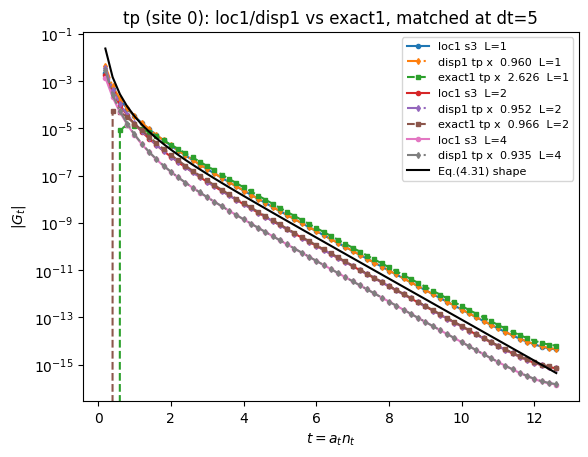

In [2]:
# tp ( = G_t): loc1 s3 (site 0) + disp1 tp (site 0) vs exact1 tp (site 0), L=1,2,4.  Matched at dt=ref.
# (exact1 has no L=4; that curve simply drops out.)
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2, 4]:
    gl = None
    try:
        gl = loc1_Gt(L)
        plt.plot(t, -gl[dt], 'o-', ms=3, label='loc1 s3  L=%d' % L)
    except (OSError, KeyError):
        print('loc1 tp L=%d missing' % L)
    try:
        gdt = disp1_Gt(L)
        cdt = (gl[ref]/gdt[ref]) if gl is not None else 1.0
        print('tp L=%d: disp1/loc1  match const = % .4f  (sign %+d)' % (L, 1.0/cdt, int(np.sign(cdt))))
        plt.plot(t, -gdt[dt], 'd-.', ms=3, label='disp1 tp x % .3f  L=%d' % (cdt, L))
    except (OSError, KeyError):
        print('disp1 tp L=%d missing' % L)
    try:
        ge = ex_Gt(L)
        c = (gl[ref]/ge[ref]) if gl is not None else 1.0
        print('tp L=%d: exact1/loc1 match const = % .4f  (sign %+d)' % (L, 1.0/c, int(np.sign(c))))
        plt.plot(t, -ge[dt], 's--', ms=3, label='exact1 tp x % .3f  L=%d' % (c, L))
    except (OSError, KeyError):
        print('exact1 tp L=%d missing' % L)
try:
    A = loc1_Gt(1)[ref] / cft_shape(t[ref-1])
    plt.plot(t, -A*cft_shape(t), 'k-', label='Eq.(4.31) shape')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_t|$')
plt.title('tp (site 0): loc1/disp1 vs exact1, matched at dt=%d' % ref); plt.legend(fontsize=8)
plt.savefig('comp_threesome1_tp.pdf', bbox_inches='tight')

sp L=1: disp1/loc1   match const =  0.5598  (sign +1)
sp L=1: exact1/loc1  match const =  0.5157  (sign +1)
sp L=2: disp1/loc1   match const =  0.5443  (sign +1)
sp L=2: exact1/loc1  match const =  0.5547  (sign +1)
sp L=4: disp1/loc1   match const =  0.5158  (sign +1)
exact1 sp L=4 missing


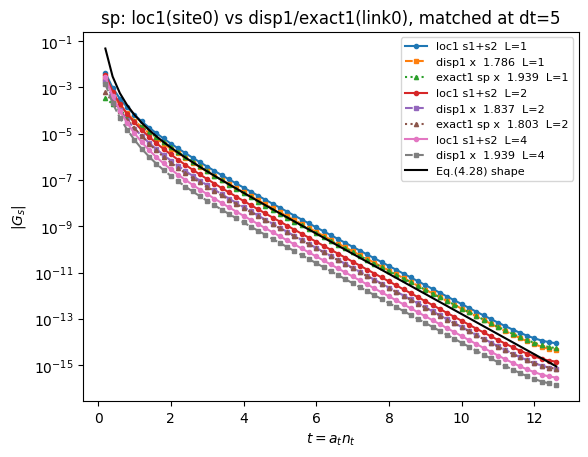

In [3]:
# sp ( = G_s): loc1 s1+s2 (site 0) vs disp1 (link 0) vs exact1 sp (link 0), L=1,2,4.  Matched at dt=ref.
# Headline: do disp1 and exact1 (SAME link 0) share sign?  loc1 is the on-site sp variant.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
for L in [1, 2, 4]:
    gl = None
    try:
        gl = loc1_Gs(L)
        plt.plot(t, gl[dt], 'o-', ms=3, label='loc1 s1+s2  L=%d' % L)
    except (OSError, KeyError):
        print('loc1 sp L=%d missing' % L)
    try:
        gd = disp1_Gs(L)
        cd = (gl[ref]/gd[ref]) if gl is not None else 1.0
        print('sp L=%d: disp1/loc1   match const = % .4f  (sign %+d)' % (L, 1.0/cd, int(np.sign(cd))))
        plt.plot(t, gd[dt], 's--', ms=3, label='disp1 x % .3f  L=%d' % (cd, L))
    except (OSError, KeyError):
        print('disp1 sp L=%d missing' % L)
    try:
        ge = ex_Gs(L)
        ce = (gl[ref]/ge[ref]) if gl is not None else 1.0
        print('sp L=%d: exact1/loc1  match const = % .4f  (sign %+d)' % (L, 1.0/ce, int(np.sign(ce))))
        plt.plot(t, ge[dt], '^:', ms=3, label='exact1 sp x % .3f  L=%d' % (ce, L))
    except (OSError, KeyError):
        print('exact1 sp L=%d missing' % L)
try:
    A = loc1_Gs(1)[ref] / cft_shape(t[ref-1])
    plt.plot(t, A*cft_shape(t), 'k-', label='Eq.(4.28) shape')
except (OSError, KeyError):
    pass
plt.yscale('log'); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$|G_s|$')
plt.title('sp: loc1(site0) vs disp1/exact1(link0), matched at dt=%d' % ref); plt.legend(fontsize=8)
plt.savefig('comp_threesome1_sp.pdf', bbox_inches='tight')

In [4]:
# SIGN table at dt=5 (raw single-insertion values; no matching).  Same sign => agree.
print('%-6s %-13s %-13s %-13s | %-15s %-13s %-13s' % (
    'L','loc1_Gt','disp1_tp','exact1_tp','loc1_Gs','disp1_sp','exact1_sp'))
for L in [1, 2, 4]:
    def g(f):
        try: return '% .3e' % f(L)[5]
        except (OSError, KeyError): return '   --      '
    print('L=%-4d %-13s %-13s %-13s | %-15s %-13s %-13s' % (
        L, g(loc1_Gt), g(disp1_Gt), g(ex_Gt), g(loc1_Gs), g(disp1_Gs), g(ex_Gs)))
print('\n(tp site 0: loc1_s3 / disp1_tp vs exact1_tp.  sp link 0: loc1 / disp1 vs exact1_sp -- if the')
print(' ultralocal (loc1/disp1) flip vs exact1 that is the genuine GW/resolvent dressing of K.)')

L      loc1_Gt       disp1_tp      exact1_tp     | loc1_Gs         disp1_sp      exact1_sp    
L=1    -3.287e-05    -3.423e-05    -1.252e-05    |  6.573e-05       3.679e-05     3.390e-05   
L=2    -1.542e-05    -1.619e-05    -1.596e-05    |  3.083e-05       1.678e-05     1.710e-05   
L=4    -5.249e-06    -5.615e-06       --         |  1.050e-05       5.415e-06       --        

(tp site 0: loc1_s3 / disp1_tp vs exact1_tp.  sp link 0: loc1 / disp1 vs exact1_sp -- if the
 ultralocal (loc1/disp1) flip vs exact1 that is the genuine GW/resolvent dressing of K.)


In [ ]:
# RATIO -G_s/G_t (log axis), qed3int_v2-13: per-direction CFT value is 1.  G_s is the projector-averaged
#   spatial correlator -- loc1 = (s1+s2)/(D-1) (both dirs averaged), disp1/exact1 = single link (one dir,
#   already per-direction).  So all three -> -1 (i.e. 1 here).  exact1 = bare K/kappa (like disp); the
#   exact1-vs-disp1 gap is the GW resolvent dressing.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft; ref = 5
plt.figure()
print('%-6s %-16s %-16s %-16s' % ('L','loc1 Gs/Gt','disp1 Gs/Gt','exact1 Gs/Gt'))
for L in [1, 2, 4]:
    sl = sd = se = '   --   '
    try:
        rl = loc1_Gs(L) / loc1_Gt(L)
        plt.plot(t, -rl[dt], 'o-', ms=3, label='loc1  L=%d' % L)
        sl = '% .4f' % rl[ref]
    except (OSError, KeyError):
        pass
    try:
        rd = disp1_Gs(L) / disp1_Gt(L)
        plt.plot(t, -rd[dt], 'd-.', ms=3, label='disp1  L=%d' % L)
        sd = '% .4f' % rd[ref]
    except (OSError, KeyError):
        pass
    try:
        re = ex_Gs(L) / ex_Gt(L)
        plt.plot(t, -re[dt], '^:', ms=3, label='exact1  L=%d' % L)
        se = '% .4f' % re[ref]
    except (OSError, KeyError):
        pass
    print('L=%-4d %-16s %-16s %-16s' % (L, sl, sd, se))
plt.axhline(1.0, color='k', lw=1, ls='-', label=r'CFT $|G_s/G_t|=1$ (v2-13)')
plt.yscale("log"); plt.xlabel(r'$t = a_t n_t$'); plt.ylabel(r'$-G_s/G_t$')
plt.title(r'own-operator ratio $G_s/G_t \to -1$ (v2-13, $1/(D-1)$ average)'); plt.legend(fontsize=8)
plt.savefig('comp_threesome1_ratio.pdf', bbox_inches='tight')
print('\n(loc1 = (s1+s2)/(D-1); disp1/exact1 = single link.  All -> -1.  exact1 vs disp1 = GW dressing.)')